# cuban worked examples

[cuban](https://github.com/burgshrimps/cuban) renders structural-variant (SV) evidence
straight from a BAM file: coverage, insert-size outliers, discordant read-pair
orientation, and the individual read alignments around each breakpoint, stacked into
one figure per sample. This notebook drives the Python API directly (`cuban.cuban(...)`)
rather than the `cuban` command-line tool, so you can call it from your own analysis code.

The example data (`examples/data/`) is synthetic and small on purpose: a 50 kb `chr1`
contig with a homozygous 5 kb deletion at `20,000-25,000`, built by
`examples/make_example_data.py`. Two BAM variants are shipped:

- `example.bam` - plain paired-end reads, no haplotype tags.
- `example_hp.bam` - the same reads, additionally tagged with an `HP` (haplotype) tag,
  so the read-alignment track can be split into per-haplotype bands.

For the full track-by-track explanation of what's in a cuban figure, see
the "Interpreting cuban plots" section of the [README](../README.md#interpreting-cuban-plots).


In [1]:
from pathlib import Path

import cuban
import cuban.repeats


def _find_repo_root() -> Path:
    """Locate the repo root from the current working directory.

    Works whether this notebook is executed from the repo root (the usual
    case for `jupyter nbconvert`) or from inside `examples/` (e.g. someone
    opened it directly in Jupyter Lab and left the cwd there).
    """
    for candidate in (Path.cwd(), Path.cwd().parent):
        if (candidate / "examples" / "data").is_dir():
            return candidate
    raise RuntimeError(
        "could not locate examples/data from the current working directory "
        f"({Path.cwd()}) - run from the repo root or from examples/"
    )


REPO_ROOT = _find_repo_root()
DATA_DIR = REPO_ROOT / "examples" / "data"

rep_df = cuban.repeats.load_repeats(str(DATA_DIR / "repeats.tsv"))
rep_df


,genoName,genoStart,genoEnd,repClass
0,chr1,19500,19800,LINE
1,chr1,19900,20100,SINE
2,chr1,24800,25300,Simple_repeat
3,chr1,30000,30500,LTR


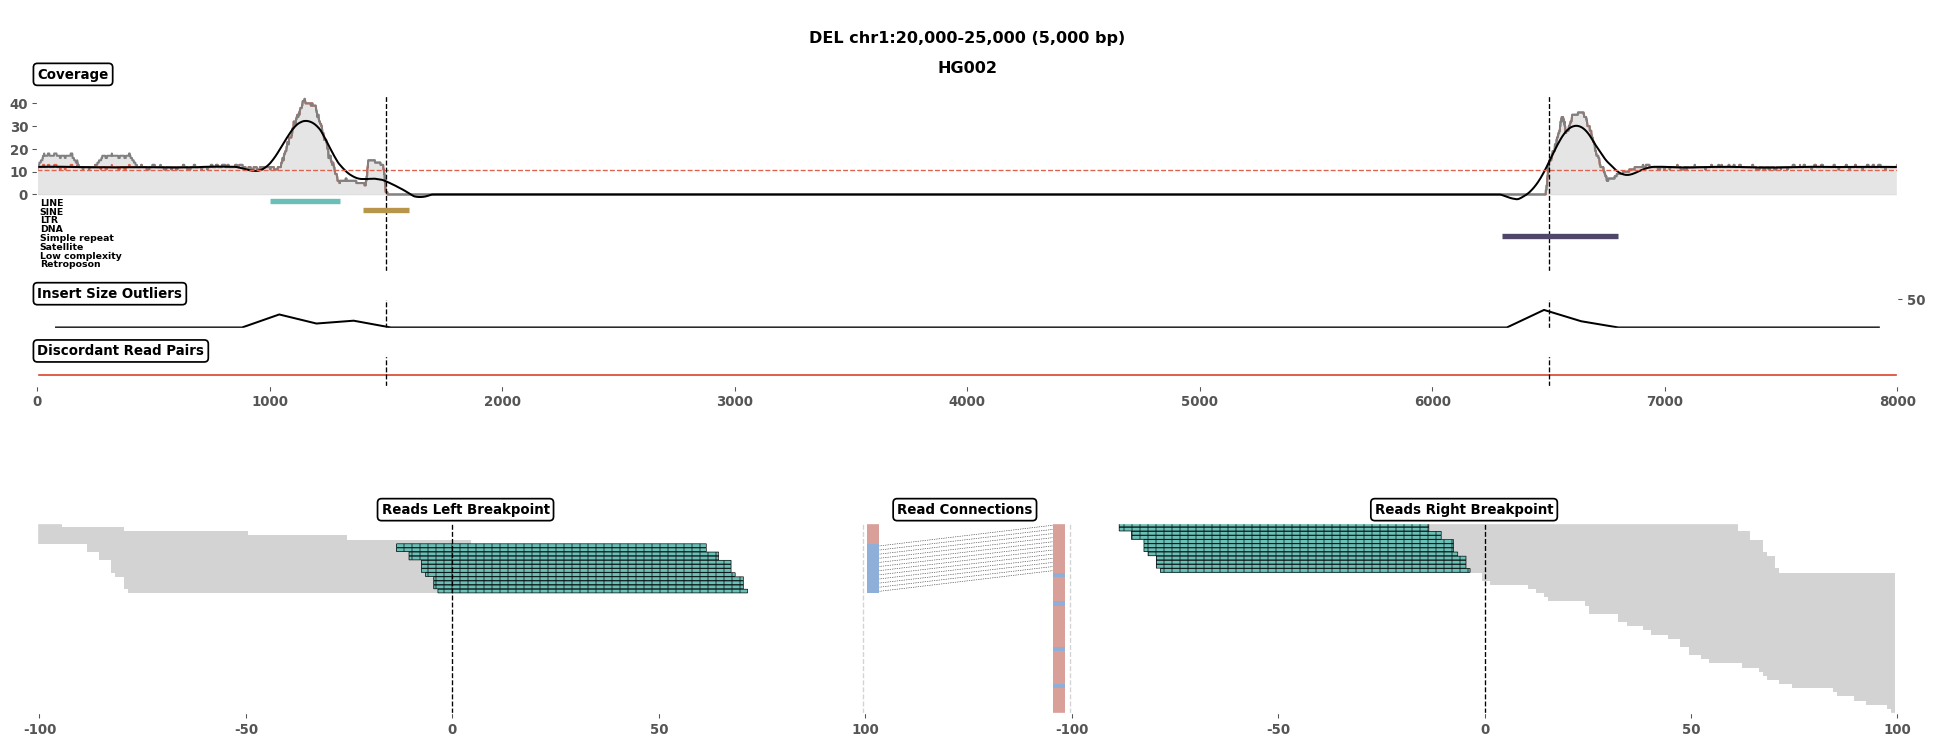

In [2]:
import contextlib
import io
import tempfile

from IPython.display import Image

# cuban.cuban() takes a dict keyed by sample name; each value is itself a dict
# describing that one sample. Every key below is required except
# 'coverage_dir', which is optional. See the last cell of this notebook for
# the full contract.
samples = {
    "HG002": {
        "technology": "ill",           # "ill" (short-read) or "pb" (long-read) - selects which tracks get drawn
        "bam_name": str(DATA_DIR / "example.bam"),
        "baseline_cov": "auto",        # or a float; "auto" estimates the chromosome's average depth from the BAM itself
        # "coverage_dir": "...",       # optional: a precomputed mosdepth output directory, to skip recomputing coverage
    }
}

# mosdepth (if installed) or the pysam fallback caches its per-chromosome
# coverage here so repeated calls for the same BAM/chromosome are fast; a
# fresh temp directory keeps this notebook run self-contained.
cache_dir = tempfile.mkdtemp(prefix="cuban_cache_")
out_png = Path(tempfile.mkdtemp(prefix="cuban_out_")) / "del_example.png"

# cuban prints a one-line progress notice (with the BAM's full local path) to
# stderr while mosdepth runs; silenced here so this notebook's saved output
# doesn't embed a machine-specific path.
with contextlib.redirect_stderr(io.StringIO()):
    cuban.cuban(
        samples=samples,
        rep_df=rep_df,
        sv_type="DEL",
        chrom="chr1",
        start=20_000,
        end=25_000,
        outfile=str(out_png),
        cache_dir=cache_dir,
    )

Image(filename=str(out_png))


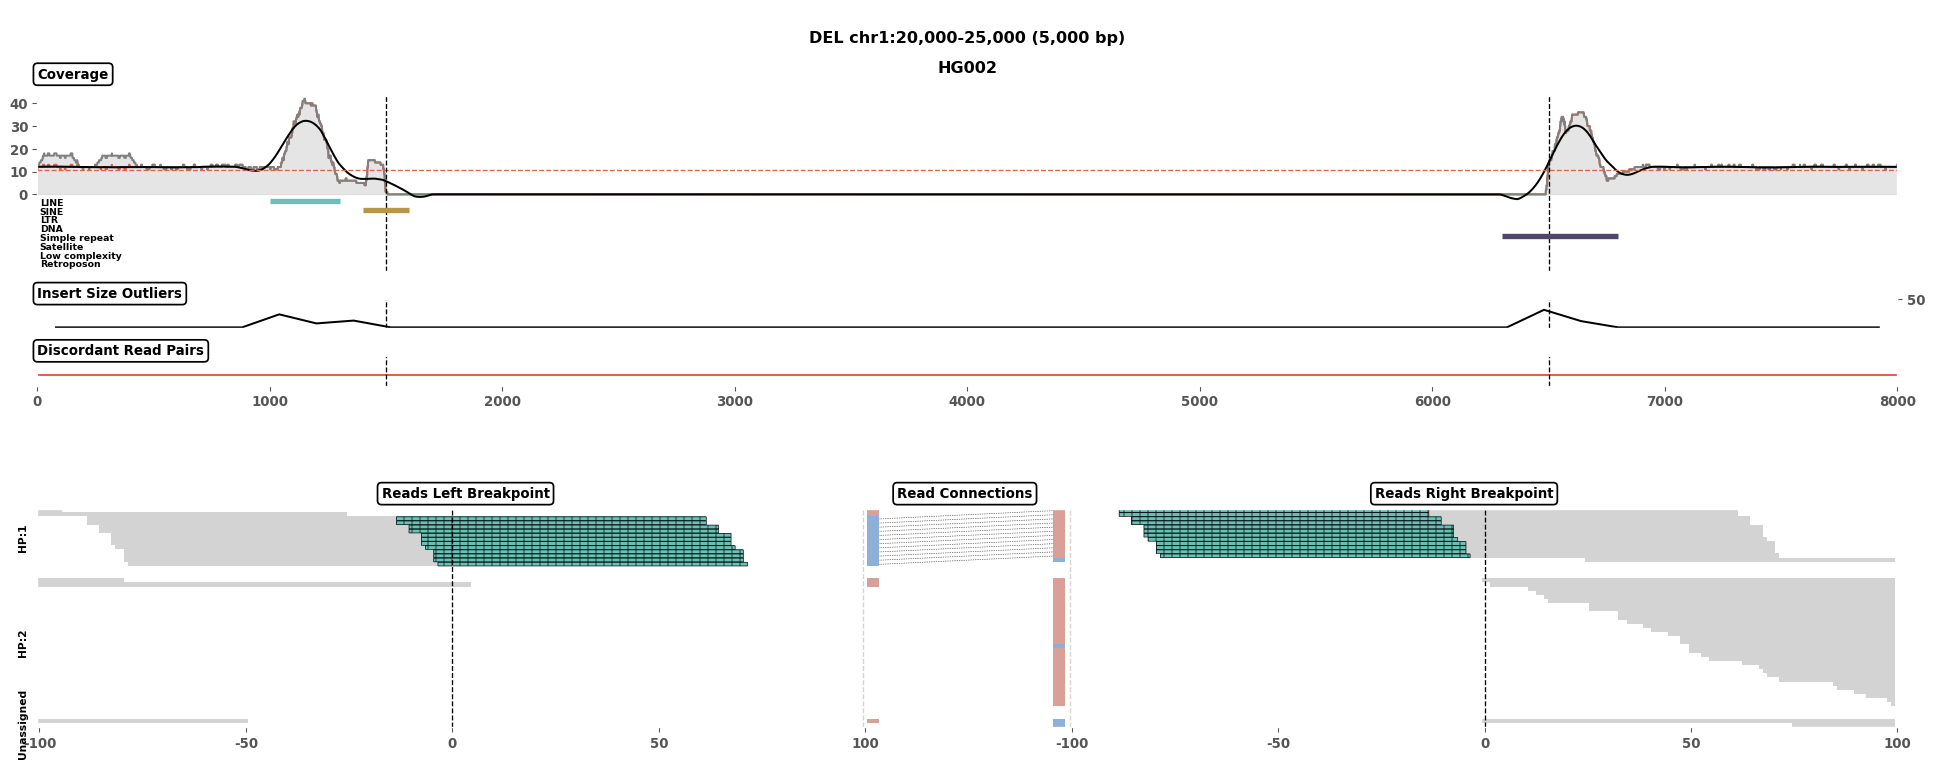

In [3]:
# Same deletion, but rendered from the HP-tagged BAM. cuban detects the HP
# tag automatically and splits the read-alignment track into one band per
# haplotype instead of a single pooled band - useful for confirming a
# variant is heterozygous/phased consistently, or (as here) that a
# homozygous call is supported on both haplotypes.
samples_hp = {
    "HG002": {
        "technology": "ill",
        "bam_name": str(DATA_DIR / "example_hp.bam"),
        "baseline_cov": "auto",
    }
}

out_png_hp = Path(tempfile.mkdtemp(prefix="cuban_out_")) / "del_example_hp.png"

with contextlib.redirect_stderr(io.StringIO()):
    cuban.cuban(
        samples=samples_hp,
        rep_df=rep_df,
        sv_type="DEL",
        chrom="chr1",
        start=20_000,
        end=25_000,
        outfile=str(out_png_hp),
        cache_dir=cache_dir,
    )

Image(filename=str(out_png_hp))


## The `samples` dict contract

`cuban.cuban(...)` and `cuban.cuban_bnd(...)` both take `samples` as their first
argument: a dict keyed by sample name, where each value is a dict with these keys.

| Key              | Type          | Meaning |
|------------------|---------------|---------|
| `technology`     | str           | `"ill"` (short-read/Illumina) or `"pb"` (long-read). Determines which tracks are drawn: `"ill"` gets coverage, insert-size, orientation and read-alignment tracks; `"pb"` gets coverage and read-alignment only, since insert size and pair orientation are Illumina-only signals. |
| `bam_name`       | str           | Path to the sample's (indexed) BAM file. |
| `baseline_cov`   | float \| `"auto"` | The chromosome's average depth, used to draw the red dashed baseline in the coverage track. `"auto"` estimates it from the BAM itself at render time. |
| `coverage_dir`   | str, optional | Path to a precomputed `mosdepth` output directory for this sample, to skip recomputing coverage from the BAM. |

The CLI (`cuban --sample name:tech:bam[:baseline_cov[:family[:disease]]]`) builds
exactly this dict from its `--sample` flags, so anything you can express in the
`samples` dict here you can also express on the command line, and vice versa.

For what each resulting track actually shows and how to read it, see
the "Interpreting cuban plots" section of the [README](../README.md#interpreting-cuban-plots).
